<div style="background: linear-gradient(135deg, #9400D3, #0000ff); padding: 20px; border-radius: 8px; color: white; font-weight: bold; text-align: center;">

# 💹Detecção de Anomalias em Transações em Python

</div>


<div style="background: linear-gradient(135deg, #9400D3, #0000ff); padding: 20px; border-radius: 8px; color: white; font-weight: bold; text-align: center;"><div style="text-align: left;">

### ➡️A Feature Engineering: Logarítmico + Padronização
---

- A feature (Amount) não segue uma distribuição bem comportada, então para correção:
- O Logaritmo, transforma ela em padrões normais de distribuição, ou seja, distruibuição normal. Se aplica isso com (log1p).
- A padronização centraliza tudo na média 0 com desvio padrão 1, colocando todas as features na mesma régua de igualdade. Se aplica isso com (StandarScaler).

</div>

<div style="background: linear-gradient(135deg, #9400D3, #0000ff); padding: 20px; border-radius: 8px; color: white; font-weight: bold; text-align: center;"><div style="text-align: left;">


### ➡️A Decisão Estratégica: Mudar o Threshold para 0.3
---
- Ao reduzir o limite para 0.3 (30%), tornamos o modelo mais sensível e preventivo.
- Consequência prática: O Recall aumenta (pegamos mais fraudes), mas a Precision cai um pouco (mais clientes inocentes terão suas compras enviadas para análise ou temporariamente retidas). É uma decisão de apetite de risco da diretoria do banco.

</div>

<div style="background: linear-gradient(135deg, #9400D3, #0000ff); padding: 20px; border-radius: 8px; color: white; font-weight: bold; text-align: center;"><div style="text-align: left;">

### ➡️A Curva Precision-Recall: Ela ignora as transações legítimas acertadas e foca no que importa.
---

- Recall: De todas as fraudes reais que aconteceram, quantas o banco pegou?
- Precision: De todos os alarmes de fraude que o modelo disparou, quantos eram fraudes reais e quantos eram clientes bons sendo bloqueados?
- O gráfico ideal busca uma linha que se estenda até o canto superior direito (alto Recall e alta Precision ao mesmo tempo).

</div>

<div style="background: linear-gradient(135deg, #9400D3, #0000ff); padding: 20px; border-radius: 8px; color: white; font-weight: bold; text-align: center;"><div style="text-align: left;">

### ➡️A Curva Precision-Recall para todos os thresholds possíveis do XGBoost
---
-  Este gráfico expõe um cabo de guerra inevitável
- Se movermos o limite para a esquerda (perto de 0.10), blindamos o banco contra prejuízos (Recall quase 100%), mas por exmplo bloquea-se clientes bons nas filas dos supermercados por engano (Precision despenca).
- Se movermos o limite para a direita (perto de 0.80), garantimos compras fluidas e sem atrito para os clientes (Precision alta), mas o banco amargará prejuízos milionários porque os fraudadores passarão direto pelo sistema (Recall despenca).
- A posição 0.3 definida no código é o ponto de equilíbrio técnico onde o XGBoost consegue entregar o maior nível de proteção financeira possível com o menor impacto operacional no atendimento ao cliente legítimo.

</div>

<div style="background: linear-gradient(135deg, #9400D3, #0000ff); padding: 20px; border-radius: 8px; color: white; font-weight: bold; text-align: center;"><div style="text-align: left;">

### ➡️A escalabilidade SHAP
---

- Indica quais indicadores merecem mais atenção. Se uma variável específica aparecer com uma barra gigantesca no topo, o time de analistas de fraude sabe que qualquer anomalia naquela métrica específica é um sinal de alerta vermelho imediato, ajudando a refinar regras manuais de segurança complementares e a entender a estratégia atual dos fraudadores.
- A resolução que o SHAP entrega é a resposta para o porquê de o modelo considerar certas transações como fraudes. Ele transforma uma floresta opaca de árvores de decisão (XGBoost) em uma lista limpa e ordenada de motivos fiscais e comportamentais.

</div>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

In [7]:
# 1 - Coleta de Dados
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
# 2 - Divisão Inicial (Essencial fazer antes de qualquer transformação ou SMOTE)
X = df.drop(columns=['Class', 'Time']) # Remove Time e Class
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

In [28]:
# 3 - Feature Engineering
# Cópia para evitar avisos do pandas
X_train_trans = X_train.copy()
X_test_trans = X_test.copy()

# Aplica Log apenas na coluna Amount (substituindo a original para não duplicar)
X_train_trans['Amount'] = np.log1p(X_train['Amount'])
X_test_trans['Amount'] = np.log1p(X_test['Amount'])

# Padronização correta: fit no treino, transforma no teste
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_trans), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_trans), columns=X.columns)

In [ ]:
# 4 - Balanceamento de dados (Aplicado apenas no treino)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [37]:
# 5 - Modelo Base (Logistic Regression)
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_res, y_train_res)

# Extração correta de probabilidades para o Threshold 0.3
y_probs_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_custom_lr = (y_probs_lr > 0.3).astype(int)

print("MÉTRICAS: REGRESSÃO LOGÍSTICA")
print(classification_report(y_test, y_pred_custom_lr))

MÉTRICAS: REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     85295
           1       0.03      0.89      0.06       148

    accuracy                           0.95     85443
   macro avg       0.52      0.92      0.52     85443
weighted avg       1.00      0.95      0.97     85443



In [36]:
# 6 - Modelo Avançado (XGBoost)
# Retirado o scale_pos_weight pois a base já foi balanceada pelo SMOTE
xgb = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    eval_metric="logloss"
)

xgb.fit(X_train_res, y_train_res)

# Extração correta de probabilidades para o Threshold 0.3
y_probs_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_custom_xgb = (y_probs_xgb > 0.3).astype(int)

print("MÉTRICAS: XGBOOST")
print(classification_report(y_test, y_pred_custom_xgb))

MÉTRICAS: XGBOOST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.35      0.82      0.50       148

    accuracy                           1.00     85443
   macro avg       0.68      0.91      0.75     85443
weighted avg       1.00      1.00      1.00     85443



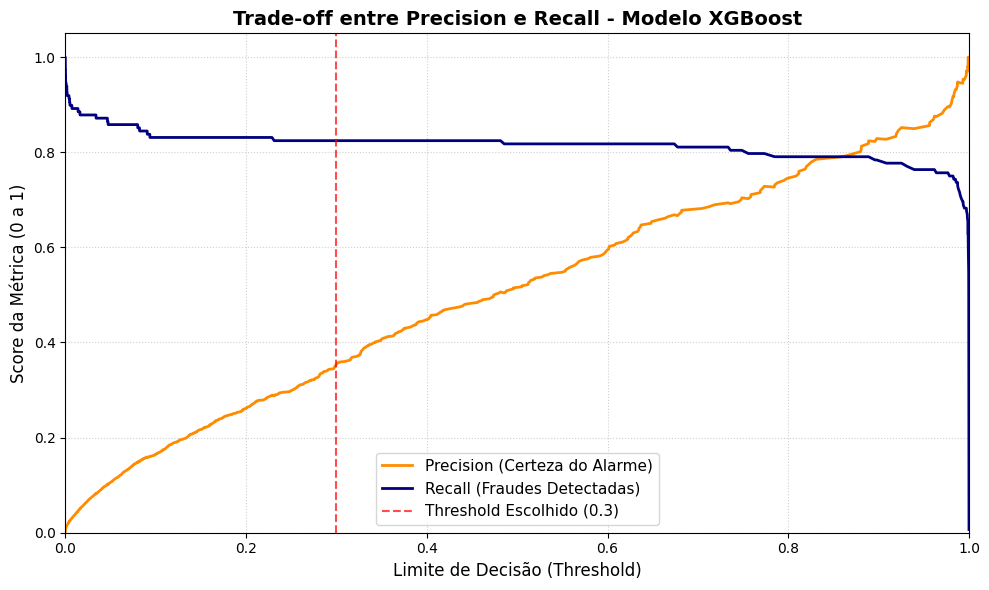

In [ ]:
# 7 - Calcular Precision e Recall para todos os thresholds possíveis do XGBoost
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_xgb)

# Como a lista de thresholds tem um elemento a menos, ajustamos o tamanho para o gráfico
plt.figure(figsize=(10, 6))

# Plotar as linhas de Precision e Recall no mesmo gráfico
plt.plot(thresholds, precisions[:-1], label="Precision (Certeza do Alarme)", color="darkorange", linewidth=2)
plt.plot(thresholds, recalls[:-1], label="Recall (Fraudes Detectadas)", color="navy", linewidth=2)

# Adicionar uma linha vertical indicando a nossa escolha atual (0.3)
plt.axvline(x=0.3, color="red", linestyle="--", alpha=0.7, label="Threshold Escolhido (0.3)")

# Configurações visuais do gráfico
plt.title("Trade-off entre Precision e Recall - Modelo XGBoost", fontsize=14, fontweight='bold')
plt.xlabel("Limite de Decisão (Threshold)", fontsize=12)
plt.ylabel("Score da Métrica (0 a 1)", fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower center", fontsize=11)

plt.tight_layout()
plt.show()

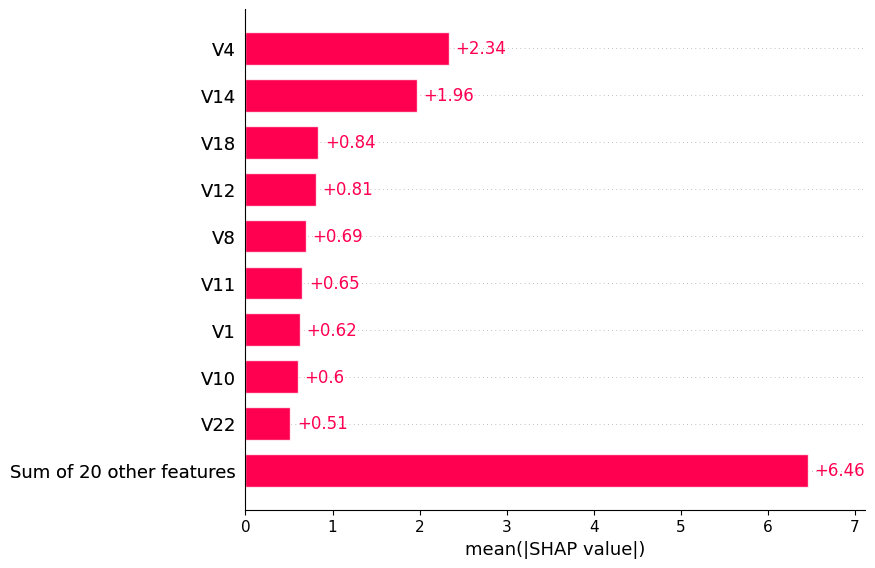

In [39]:
# 8 - Explicabilidade (SHAP)
# Ajustado para TreeExplainer que é o correto e rápido para modelos baseados em árvores
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test_scaled.iloc[:100])

# Plot de barras do SHAP
shap.plots.bar(shap_values)